In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = {
    'Age_Group': ['18-25', '26-35', '36-45', '46-60', '60+',
                 '18-25', '26-35', '36-45', '46-60', '60+',
                 '18-25', '26-35', '36-45', '46-60', '60+'],
    'Income': [25000, 45000, 55000, 70000, 40000,
              27000, 47000, 60000, 72000, 38000,
              28000, 46000, 54000, 69000, 39000]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,Age_Group,Income
0,18-25,25000
1,26-35,45000
2,36-45,55000
3,46-60,70000
4,60+,40000


In [5]:
summary_stats = df.groupby('Age_Group')['Income'].describe()
summary_stats

,count,mean,std,min,25%,50%,75%,max
Age_Group,,,,,,,,
18-25,3.0,26666.666667,1527.525232,25000.0,26000.0,27000.0,27500.0,28000.0
26-35,3.0,46000.000000,1000.000000,45000.0,45500.0,46000.0,46500.0,47000.0
36-45,3.0,56333.333333,3214.550254,54000.0,54500.0,55000.0,57500.0,60000.0
46-60,3.0,70333.333333,1527.525232,69000.0,69500.0,70000.0,71000.0,72000.0
60+,3.0,39000.000000,1000.000000,38000.0,38500.0,39000.0,39500.0,40000.0


In [6]:
income_stats = df.groupby('Age_Group')['Income'].agg(['mean', 'std', 'min', 'max', 'median', 'count'])
income_stats

,mean,std,min,max,median,count
Age_Group,,,,,,
18-25,26666.666667,1527.525232,25000,28000,27000.0,3
26-35,46000.000000,1000.000000,45000,47000,46000.0,3
36-45,56333.333333,3214.550254,54000,60000,55000.0,3
46-60,70333.333333,1527.525232,69000,72000,70000.0,3
60+,39000.000000,1000.000000,38000,40000,39000.0,3


In [7]:
income_values_by_age_group = df.groupby('Age_Group')['Income'].apply(list)
income_values_by_age_group

Age_Group
18-25    [25000, 27000, 28000]
26-35    [45000, 47000, 46000]
36-45    [55000, 60000, 54000]
46-60    [70000, 72000, 69000]
60+      [40000, 38000, 39000]
Name: Income, dtype: object

In [8]:
percentiles = df.groupby('Age_Group')['Income'].quantile([0.25, 0.5, 0.75])
percentiles

Age_Group      
18-25      0.25    26000.0
           0.50    27000.0
           0.75    27500.0
26-35      0.25    45500.0
           0.50    46000.0
           0.75    46500.0
36-45      0.25    54500.0
           0.50    55000.0
           0.75    57500.0
46-60      0.25    69500.0
           0.50    70000.0
           0.75    71000.0
60+        0.25    38500.0
           0.50    39000.0
           0.75    39500.0
Name: Income, dtype: float64

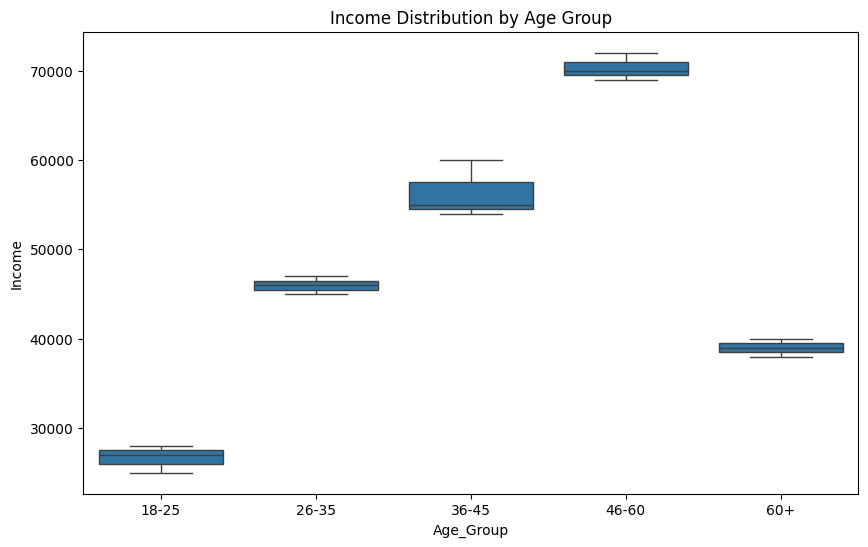

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Age_Group', y='Income', data=df)
plt.title('Income Distribution by Age Group')
plt.show()

In [10]:
from sklearn.datasets import load_iris

In [11]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['Species'] = iris.target

In [12]:
df_iris['Species'] = df_iris['Species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
iris_stats = df_iris.groupby('Species').describe()
iris_stats

sepal length (cm)                                              \
                       count   mean       std  min    25%  50%  75%  max   
Species                                                                    
setosa                  50.0  5.006  0.352490  4.3  4.800  5.0  5.2  5.8   
versicolor              50.0  5.936  0.516171  4.9  5.600  5.9  6.3  7.0   
virginica               50.0  6.588  0.635880  4.9  6.225  6.5  6.9  7.9   

           sepal width (cm)         ... petal length (cm)       \
                      count   mean  ...               75%  max   
Species                             ...                          
setosa                 50.0  3.428  ...             1.575  1.9   
versicolor             50.0  2.770  ...             4.600  5.1   
virginica              50.0  2.974  ...             5.875  6.9   

           petal width (cm)                                            
                      count   mean       std  min  25%  50%  75%  max  
Species                                                                
setosa                 50.0  0.246  0.105386  0.1  0.2  0.2  0.3  0.6  
versicolor             50.0  1.326  0.197753  1.0  1.2  1.3  1.5  1.8  
virginica              50.0  2.026  0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]